In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '8'
os.environ['MKL_NUM_THREADS'] = '8'
os.environ['OPENBLAS_NUM_THREADS'] = '8'
os.environ['NUMEXPR_NUM_THREADS'] = '8'
os.environ['VECLIB_MAXIMUM_THREADS'] = '8'

print("? Thread limits set to 8 in this notebook")

? Thread limits set to 8 in this notebook


In [1]:
# ==================== CELL 1: GraphSAGE Setup, training, and attack utilities ====================
import os
import random
import ast
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ---------- Reproducibility ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---------- Load dataset ----------
CSV_PATH = "all_circuits_features.csv"   # your CSV
df = pd.read_csv(CSV_PATH)

print("\nDataset head:")
print(df.head())

# ---------- Label encode gate_type ----------
label_encoder = LabelEncoder()
df["gate_label"] = label_encoder.fit_transform(df["gate_type"])

# ---------- Feature columns ----------
feature_columns = [
    "fan_in", "fan_out", "dist_to_output", "is_primary_input", "is_primary_output",
    "is_internal", "is_key_gate", "degree_centrality", "betweenness_centrality",
    "closeness_centrality", "clustering_coefficient", "avg_fan_in_neighbors", "avg_fan_out_neighbors"
]

df = df.dropna(subset=feature_columns).reset_index(drop=True)
df[feature_columns] = df[feature_columns].astype(float)

# ---------- Standardize ----------
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# ---------- Build nodes & edges ----------
nodes = df["node"].tolist()
node_to_id = {node: i for i, node in enumerate(nodes)}

edges = []
for idx, row in df.iterrows():
    node_id = node_to_id[row["node"]]
    potential_sources = df[df["fan_out"] > 0]["node"].tolist()
    sources = potential_sources[:int(row["fan_in"])] if int(row["fan_in"]) > 0 else []
    for src in sources:
        if src in node_to_id:
            edges.append((node_to_id[src], node_id))

print(f"\nExtracted {len(edges)} edges (approximate fan-in construction).")
if len(edges) == 0:
    raise ValueError("No edges found! Check fan_in/fan_out in CSV.")

src_nodes, dst_nodes = zip(*edges)
src_tensor = torch.tensor(src_nodes, dtype=torch.int64)
dst_tensor = torch.tensor(dst_nodes, dtype=torch.int64)

valid_edges = (src_tensor >= 0) & (dst_tensor >= 0) & (src_tensor < len(nodes)) & (dst_tensor < len(nodes))
src_tensor = src_tensor[valid_edges]
dst_tensor = dst_tensor[valid_edges]

# ---------- DGL graph ----------
graph = dgl.graph((src_tensor, dst_tensor), num_nodes=len(nodes))
graph = dgl.add_self_loop(graph)

graph.ndata['features'] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
graph.ndata['labels'] = torch.tensor(df["gate_label"].values, dtype=torch.long)

# ---------- Train-test split ----------
num_nodes = graph.num_nodes()
indices = np.arange(num_nodes)
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=SEED)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

# ---------- Define GraphSAGE ----------
class GraphSAGE(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GraphSAGE, self).__init__()
        self.conv1 = dglnn.SAGEConv(in_feats, hidden_feats, aggregator_type='mean')
        self.conv2 = dglnn.SAGEConv(hidden_feats, out_feats, aggregator_type='mean')

    def forward(self, g, inputs):
        x = self.conv1(g, inputs)
        x = torch.relu(x)
        x = self.conv2(g, x)
        return x

in_feats = len(feature_columns)
hidden_feats = 32
out_feats = len(label_encoder.classes_)
model = GraphSAGE(in_feats, hidden_feats, out_feats)

# ---------- Move to device ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
graph = graph.to(device)
graph.ndata['features'] = graph.ndata['features'].to(device)
graph.ndata['labels'] = graph.ndata['labels'].to(device)
train_mask = train_mask.to(device)
test_mask = test_mask.to(device)

# ---------- Train ----------
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

epochs = 50
for epoch in range(epochs):
    model.train()
    logits = model(graph, graph.ndata['features'])
    loss = loss_fn(logits[train_mask], graph.ndata['labels'][train_mask])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

# ---------- Evaluate ----------
model.eval()
with torch.no_grad():
    logits_all = model(graph, graph.ndata['features'])
    test_pred = logits_all[test_mask].argmax(dim=1)
    test_acc = (test_pred == graph.ndata['labels'][test_mask]).float().mean().item()
    train_pred = logits_all[train_mask].argmax(dim=1)
    train_acc = (train_pred == graph.ndata['labels'][train_mask]).float().mean().item()

print(f"\nTest Accuracy: {test_acc*100:.2f}%, Train Accuracy: {train_acc*100:.2f}%")

# ---------- Attack utilities ----------
EPS = 1e-8

def compute_true_grads(model, graph, target_idx):
    model.zero_grad()
    logits = model(graph, graph.ndata['features'])
    loss = loss_fn(logits[target_idx:target_idx+1], graph.ndata['labels'][target_idx:target_idx+1])
    grads = torch.autograd.grad(loss, tuple(model.parameters()), allow_unused=True)
    grads_filled = []
    for p, g in zip(model.parameters(), grads):
        grads_filled.append(torch.zeros_like(p).detach() if g is None else g.detach().clone())
    return grads_filled

def grad_inversion_with_target_grads(model, graph, target_idx, grads_target_mod,
                                     steps=300, lr=0.05, l2_reg=1e-3,
                                     normalize_paramwise=True, clamp_range=5.0, early_stop_patience=40,
                                     verbose=False):
    model.eval()
    X_orig = graph.ndata['features'].detach()
    x_true = X_orig[target_idx:target_idx+1].detach().to(device)
    y_true = graph.ndata['labels'][target_idx:target_idx+1].detach().to(device)

    x_rec = torch.randn_like(x_true, requires_grad=True, device=device)
    optimizer_rec = optim.Adam([x_rec], lr=lr)
    best_loss, best_x, stale = float('inf'), None, 0

    for it in range(steps):
        optimizer_rec.zero_grad()
        X_mod = X_orig.clone()
        X_mod[target_idx:target_idx+1] = x_rec
        logits_mod = model(graph, X_mod)
        loss_mod = loss_fn(logits_mod[target_idx:target_idx+1], y_true)
        grads_rec = torch.autograd.grad(loss_mod, tuple(model.parameters()), create_graph=True, allow_unused=True)

        total = torch.tensor(0.0, device=device)
        for gr_rec, gr_tgt in zip(grads_rec, grads_target_mod):
            if gr_rec is None: continue
            gt = gr_tgt.to(device)
            total = total + ((gr_rec - gt).pow(2).sum() / (float(gt.numel()) + EPS) if normalize_paramwise else (gr_rec - gt).pow(2).sum())
        reg = l2_reg * torch.norm(x_rec, p=2)
        objective = total + reg
        objective.backward()
        optimizer_rec.step()

        with torch.no_grad(): x_rec.clamp_(-clamp_range, clamp_range)
        cur_loss = objective.item()
        if cur_loss < best_loss - 1e-7:
            best_loss, best_x, stale = cur_loss, x_rec.detach().clone(), 0
        else:
            stale += 1
            if stale >= early_stop_patience: break

    if best_x is None: best_x = x_rec.detach().clone()
    abs_l2 = torch.norm(best_x - x_true).item()
    rel_l2 = abs_l2 / (torch.norm(x_true).item() + EPS)
    cos_sim = (torch.nn.functional.cosine_similarity(best_x.view(-1), x_true.view(-1), dim=0).item())

    return best_x.cpu(), {"abs_l2": abs_l2, "rel_l2": rel_l2, "cos_sim": cos_sim}

# ---------- Sample nodes per class ----------
unique_labels = torch.unique(graph.ndata['labels']).cpu().numpy()
sampled_nodes_per_label = {}
for lbl in unique_labels:
    train_indices = torch.where(train_mask & (graph.ndata['labels'] == int(lbl)))[0].cpu().numpy().tolist()
    k = min(20, len(train_indices))
    sampled = random.sample(train_indices, k) if len(train_indices) > 0 else []
    sampled_nodes_per_label[int(lbl)] = sampled
    pretty_name = label_encoder.inverse_transform([int(lbl)])[0]
    print(f"Label {int(lbl)} ({pretty_name}): sampling {len(sampled)} nodes")

np.save("sampled_nodes_per_label.npy", sampled_nodes_per_label)
print("\nSaved sampled nodes mapping to 'sampled_nodes_per_label.npy'.")

print("\nCELL 1 (GraphSAGE) complete. Available variables:")
print(" - graph, model, train_mask, test_mask, label_encoder, sampled_nodes_per_label")
print(" - compute_true_grads(model, graph, idx)")
print(" - grad_inversion_with_target_grads(model, graph, idx, grads_target_mod, ...)")



Dataset head:
  circuit_name node gate_type  fan_in  fan_out  \
0      adder.v   g1       not       1        1   
1      adder.v   g2       and       2        1   
2      adder.v   g3       not       1        1   
3      adder.v   g4       and       2        1   
4      adder.v   g5        or       2        1   

                                      depth  dist_to_output  is_primary_input  \
0  {'g1': 0, 'g2': 1, 'g5': 2, '\\f[0]': 3}               3                 0   
1           {'g2': 0, 'g5': 1, '\\f[0]': 2}               2                 0   
2  {'g3': 0, 'g4': 1, 'g5': 2, '\\f[0]': 3}               3                 0   
3           {'g4': 0, 'g5': 1, '\\f[0]': 2}               2                 0   
4                    {'g5': 0, '\\f[0]': 1}               1                 0   

   is_primary_output  is_internal  is_key_gate key_dependency  \
0                  0            1            0            NaN   
1                  0            1            0            NaN   
2 


GCN MODEL PERFORMANCE METRICS
Training Accuracy: 0.9358
Test Accuracy: 0.9342

Confusion Matrix:


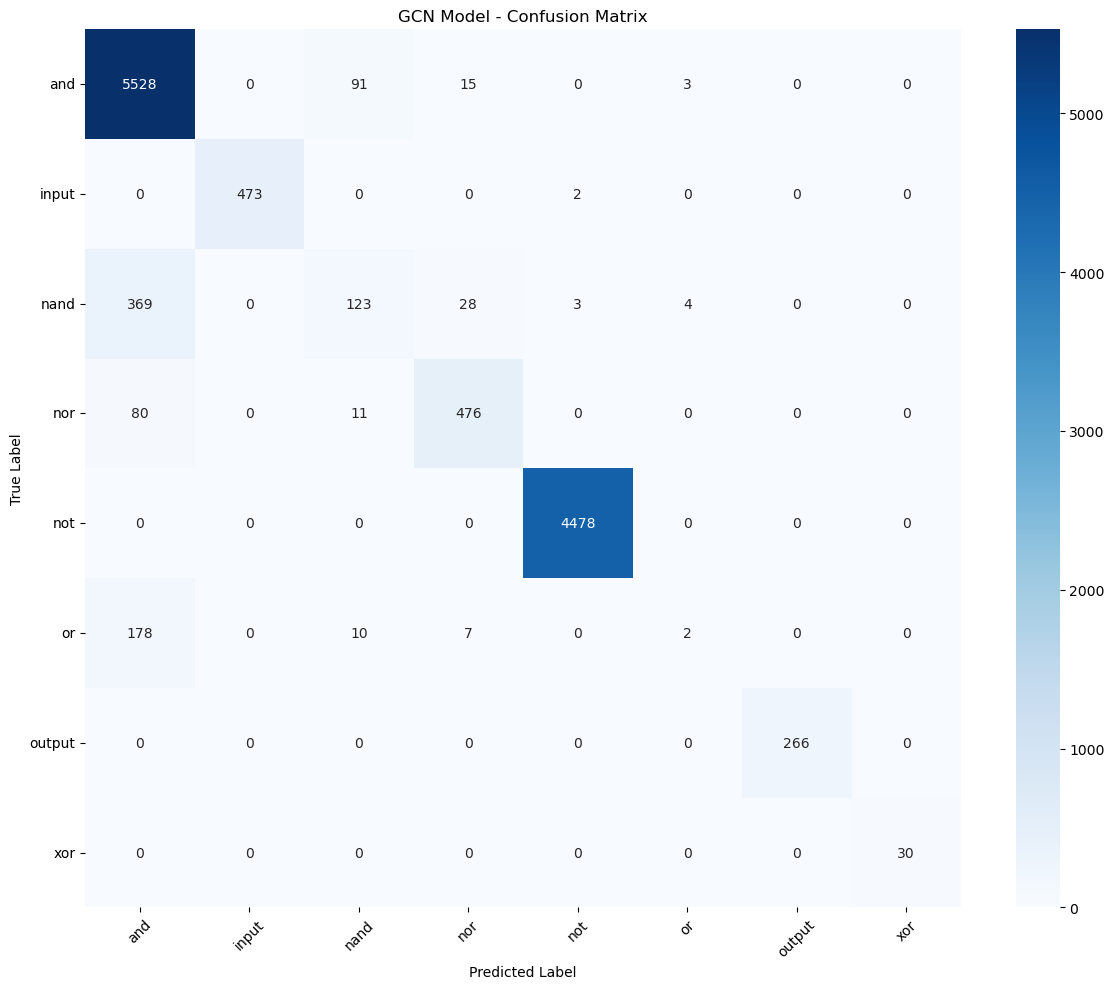


Classification Report:
              precision    recall  f1-score   support

         and       0.90      0.98      0.94      5637
       input       1.00      1.00      1.00       475
        nand       0.52      0.23      0.32       527
         nor       0.90      0.84      0.87       567
         not       1.00      1.00      1.00      4478
          or       0.22      0.01      0.02       197
      output       1.00      1.00      1.00       266
         xor       1.00      1.00      1.00        30

    accuracy                           0.93     12177
   macro avg       0.82      0.76      0.77     12177
weighted avg       0.91      0.93      0.92     12177


Overall Metrics:
Precision: 0.9148
Recall: 0.9342
F1-Score: 0.9196

Per-class Metrics:
Class and: Precision=0.8981, Recall=0.9807, F1=0.9376
Class input: Precision=1.0000, Recall=0.9958, F1=0.9979
Class nand: Precision=0.5234, Recall=0.2334, F1=0.3228
Class nor: Precision=0.9049, Recall=0.8395, F1=0.8710
Class not: Precisi

In [2]:
# Add these imports if not already present
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns

# -----------------------------------
# Evaluate GCN Model Performance
# -----------------------------------

print("\n" + "="*50)
print("GCN MODEL PERFORMANCE METRICS")
print("="*50)

# Get predictions
model.eval()
with torch.no_grad():
    # Training predictions
    train_logits = model(graph, graph.ndata['features'])
    train_pred = train_logits[train_mask].argmax(dim=1)
    train_labels = graph.ndata['labels'][train_mask]
    train_accuracy = (train_pred == train_labels).float().mean().item()
    
    # Test predictions
    test_logits = model(graph, graph.ndata['features'])
    test_pred = test_logits[test_mask].argmax(dim=1)
    test_labels = graph.ndata['labels'][test_mask]
    test_accuracy = (test_pred == test_labels).float().mean().item()

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Convert to CPU numpy for sklearn metrics
test_pred_np = test_pred.cpu().numpy()
test_labels_np = test_labels.cpu().numpy()
train_pred_np = train_pred.cpu().numpy()
train_labels_np = train_labels.cpu().numpy()

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(test_labels_np, test_pred_np)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('GCN Model - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels_np, test_pred_np, 
                          target_names=label_encoder.classes_))

# Overall Precision, Recall, F1-Score
overall_precision = precision_score(test_labels_np, test_pred_np, average='weighted')
overall_recall = recall_score(test_labels_np, test_pred_np, average='weighted')
overall_f1 = f1_score(test_labels_np, test_pred_np, average='weighted')

print("\nOverall Metrics:")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1-Score: {overall_f1:.4f}")

# Per-class metrics
print("\nPer-class Metrics:")
precision_per_class = precision_score(test_labels_np, test_pred_np, average=None)
recall_per_class = recall_score(test_labels_np, test_pred_np, average=None)
f1_per_class = f1_score(test_labels_np, test_pred_np, average=None)

for i, class_name in enumerate(label_encoder.classes_):
    print(f"Class {class_name}: Precision={precision_per_class[i]:.4f}, "
          f"Recall={recall_per_class[i]:.4f}, F1={f1_per_class[i]:.4f}")

# Additional: Training vs Test accuracy comparison
print(f"\nAccuracy Comparison:")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Gap: {abs(train_accuracy - test_accuracy)*100:.2f}%")

# Class distribution in test set
unique, counts = np.unique(test_labels_np, return_counts=True)
print(f"\nClass distribution in test set:")
for i, count in zip(unique, counts):
    class_name = label_encoder.inverse_transform([i])[0]
    print(f"  {class_name}: {count} samples ({count/len(test_labels_np)*100:.1f}%)")

In [3]:
# ==================== CELL 2: No Defense (Baseline for GraphSAGE) ====================
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

# ---------- Parameters ----------
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

# ---------- Load sampled nodes ----------
sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()

rows = []
total = sum(len(v) for v in sampled_nodes_per_label.values())
print("Total baseline attacks to run:", total)

# ---------- Loop over all sampled nodes ----------
for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"NoDef (GraphSAGE) label {label_name}"):
        # compute true grads for the target node
        grads_true = compute_true_grads(model, graph, target_idx)

        # observed grads = true grads (no defense)
        grads_obs = [g.clone() for g in grads_true]

        # run gradient inversion
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )

        rows.append({
            "defense": "None",
            "defense_key": "none",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

# ---------- Save results ----------
df_none = pd.DataFrame(rows)
df_none.to_csv("results_none_graphsage.csv", index=False)
print(f"Saved results_none_graphsage.csv (rows: {len(df_none)})")

# ---------- Per-class summary ----------
print("\nBaseline summary (GraphSAGE)  mean ± std:")
print(df_none.groupby("label_name")[["abs_l2", "rel_l2", "cos_sim"]].agg(["mean", "std", "count"]))


Total baseline attacks to run: 160


NoDef (GraphSAGE) label xor: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [21:51<00:00, 65.57s/it]

Saved results_none_graphsage.csv (rows: 160)

Baseline summary (GraphSAGE)  mean ± std:
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.582645  1.363785    20  1.235924  0.586338    20  0.298406   
input        6.017485  0.513853    20  0.877112  0.070557    20  0.559547   
nand         2.007580  1.549402    20  0.855486  0.473027    20  0.662041   
nor          3.426929  1.279554    20  0.844285  0.202962    20  0.495065   
not          2.741068  1.452019    20  1.508682  0.639721    20  0.212991   
or           1.009640  0.885833    20  0.412478  0.204471    20  0.897500   
output       7.088492  0.447949    20  0.843760  0.042438    20  0.677290   
xor         21.932071  0.990398    20  0.934018  0.024808    20  0.627650   

                            
                 std count  
label

In [4]:
# CELL 3: Gradient Clipping + Perturbation (GraphSAGE)
import numpy as np, pandas as pd, torch
from tqdm import tqdm

clip_value = 1.0
perturb_std = 0.05

recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []
total = sum(len(v) for v in sampled_nodes_per_label.values())
print("Total grad-clip attacks to run:", total)

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"GradClip label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = []
        for g in grads_true:
            g_clipped = torch.clamp(g, -clip_value, clip_value)
            g_noisy = g_clipped + torch.randn_like(g_clipped) * perturb_std
            grads_obs.append(g_noisy)
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Gradient Clipping + Perturbation",
            "defense_key": "clip_perturb",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_clip = pd.DataFrame(rows)
df_clip.to_csv("results_graphSAGE_gradclip_perturb.csv", index=False)
print(f"Saved results_graphSAGE_gradclip_perturb.csv (rows: {len(df_clip)})")
print("\nGradClip summary (mean ± std):")
print(df_clip.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


Total grad-clip attacks to run: 160


GradClip label xor: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [16:02<00:00, 48.14s/it]

Saved results_graphSAGE_gradclip_perturb.csv (rows: 160)

GradClip summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.567635  1.266454    20  1.271555  0.685415    20  0.340584   
input        6.225569  0.632755    20  0.907776  0.092251    20  0.438564   
nand         2.369267  1.845294    20  1.039124  0.611512    20  0.644326   
nor          3.556484  1.239514    20  0.878199  0.153375    20  0.513768   
not          2.623769  1.196445    20  1.508602  0.627387    20  0.116295   
or           1.288039  1.055809    20  0.531740  0.228332    20  0.862387   
output       7.323464  0.521916    20  0.871804  0.053526    20  0.590412   
xor         22.209942  1.091285    20  0.945789  0.029222    20  0.544331   

                            
                 std count  
label

In [5]:
# CELL 4: Differential Privacy (GraphSAGE)
import numpy as np, pandas as pd, torch
from tqdm import tqdm

dp_sigma = 0.1
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"DP label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = [g + torch.randn_like(g) * dp_sigma for g in grads_true]
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Differential Privacy",
            "defense_key": "dp",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_dp = pd.DataFrame(rows)
df_dp.to_csv("results_graphSAGE_dp.csv", index=False)
print(f"Saved results_graphSAGE_dp.csv (rows: {len(df_dp)})")
print("\nDP summary (mean ± std):")
print(df_dp.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


DP label xor: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [16:27<00:00, 49.37s/it]

Saved results_graphSAGE_dp.csv (rows: 160)

DP summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.475944  1.560185    20  1.122483  0.497427    20  0.366793   
input        5.864973  0.713155    20  0.855013  0.102830    20  0.601250   
nand         2.363702  1.713670    20  1.017645  0.552462    20  0.534969   
nor          3.320907  1.457909    20  0.830591  0.227223    20  0.519248   
not          2.711439  1.145575    20  1.570091  0.745586    20  0.290417   
or           1.172817  1.098852    20  0.492461  0.286985    20  0.823463   
output       7.375664  0.728711    20  0.877897  0.078440    20  0.531527   
xor         22.409962  1.149714    20  0.954176  0.027591    20  0.514443   

                            
                 std count  
label_name               

In [6]:
# CELL 5: Secure Aggregation (GraphSAGE)
import numpy as np, pandas as pd, torch, random
from tqdm import tqdm

group_size = 5
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

all_labels = graph.ndata['labels'].cpu().numpy()
train_indices = torch.where(train_mask)[0].cpu().numpy()
label_to_trainlist = {int(lbl): np.intersect1d(np.where(all_labels==lbl)[0], train_indices).tolist()
                      for lbl in np.unique(all_labels)}

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"SecAgg label {label_name}"):
        pool = label_to_trainlist.get(int(lbl), [])
        if len(pool) == 0:
            grads_obs = compute_true_grads(model, graph, target_idx)
        else:
            members = [target_idx]
            others = [i for i in pool if i != target_idx]
            k = min(len(others), group_size-1)
            if k > 0: members += random.sample(others, k)
            agg = None
            for m in members:
                g_m = compute_true_grads(model, graph, m)
                agg = [t.clone() for t in g_m] if agg is None else [a + b for a,b in zip(agg, g_m)]
            grads_obs = [a / float(len(members)) for a in agg]
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Secure Aggregation",
            "defense_key": "secure_agg",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_secure = pd.DataFrame(rows)
df_secure.to_csv("results_graphSAGE_secureagg.csv", index=False)
print(f"Saved results_graphSAGE_secureagg.csv (rows: {len(df_secure)})")
print("\nSecureAgg summary (mean ± std):")
print(df_secure.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


SecAgg label xor: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [12:44<00:00, 38.22s/it]

Saved results_graphSAGE_secureagg.csv (rows: 160)

SecureAgg summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          3.276096  1.141338    20  1.698734  0.823957    20  0.135243   
input        6.061573  0.268259    20  0.883725  0.035532    20  0.539401   
nand         2.841583  1.789369    20  1.240863  0.533850    20  0.421910   
nor          3.711854  1.302323    20  0.926348  0.139885    20  0.440218   
not          2.283534  0.998009    20  1.297217  0.575637    20  0.258152   
or           1.702263  1.061279    20  0.745665  0.213060    20  0.647372   
output       7.357008  0.526654    20  0.876026  0.058763    20  0.548738   
xor         22.315752  1.182307    20  0.950070  0.027082    20  0.535897   

                            
                 std count  
label_name 

In [7]:
# CELL 6: Model Quantization (GraphSAGE)
import numpy as np, pandas as pd, torch
from tqdm import tqdm

quant_factor = 100.0
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"Quant label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = [torch.round(g * quant_factor) / quant_factor for g in grads_true]
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Model Quantization",
            "defense_key": "quant",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_quant = pd.DataFrame(rows)
df_quant.to_csv("results_graphSAGE_quant.csv", index=False)
print(f"Saved results_graphSAGE_quant.csv (rows: {len(df_quant)})")
print("\nQuant summary (mean ± std):")
print(df_quant.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


Quant label xor: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [19:25<00:00, 58.30s/it]

Saved results_graphSAGE_quant.csv (rows: 160)

Quant summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.716623  1.508987    20  1.270207  0.617493    20  0.339405   
input        6.238984  0.516532    20  0.909756  0.075704    20  0.445777   
nand         1.700446  1.709412    20  0.713632  0.512696    20  0.745482   
nor          3.405942  1.356175    20  0.891818  0.351960    20  0.511331   
not          2.989925  0.766008    20  1.788964  0.592766    20  0.083846   
or           1.265535  1.066075    20  0.511397  0.288335    20  0.821243   
output       7.239547  0.620248    20  0.861462  0.060535    20  0.584428   
xor         22.015879  1.112118    20  0.937315  0.023248    20  0.620925   

                            
                 std count  
label_name         

In [8]:
# CELL 7: Adversarial Training style perturbation (GraphSAGE)
import numpy as np, pandas as pd, torch
from tqdm import tqdm

perturb_eps = 0.02
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"AdvTrain label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = [g + perturb_eps * torch.sign(torch.randn_like(g)) for g in grads_true]
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Adversarial Training",
            "defense_key": "adv_train",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_advtrain = pd.DataFrame(rows)
df_advtrain.to_csv("results_graphSAGE_advtrain.csv", index=False)
print(f"Saved results_graphSAGE_advtrain.csv (rows: {len(df_advtrain)})")
print("\nAdvTrain summary (mean ± std):")
print(df_advtrain.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


AdvTrain label xor: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [15:11<00:00, 45.57s/it]

Saved results_graphSAGE_advtrain.csv (rows: 160)

AdvTrain summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.516120  1.205232    20  1.236102  0.492150    20  0.316308   
input        5.980707  0.529698    20  0.871969  0.075947    20  0.529596   
nand         1.852844  1.521950    20  0.796719  0.546571    20  0.723204   
nor          3.390575  1.464992    20  0.829511  0.278527    20  0.517095   
not          2.755701  1.287775    20  1.526211  0.629055    20  0.162456   
or           0.990369  0.801711    20  0.439932  0.247883    20  0.875508   
output       7.289022  0.532079    20  0.867594  0.053973    20  0.581294   
xor         22.031458  0.991256    20  0.938192  0.022064    20  0.623857   

                            
                 std count  
label_name   

/tmp/ipykernel_129597/1155840716.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_129597/1155840716.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_129597/1155840716.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


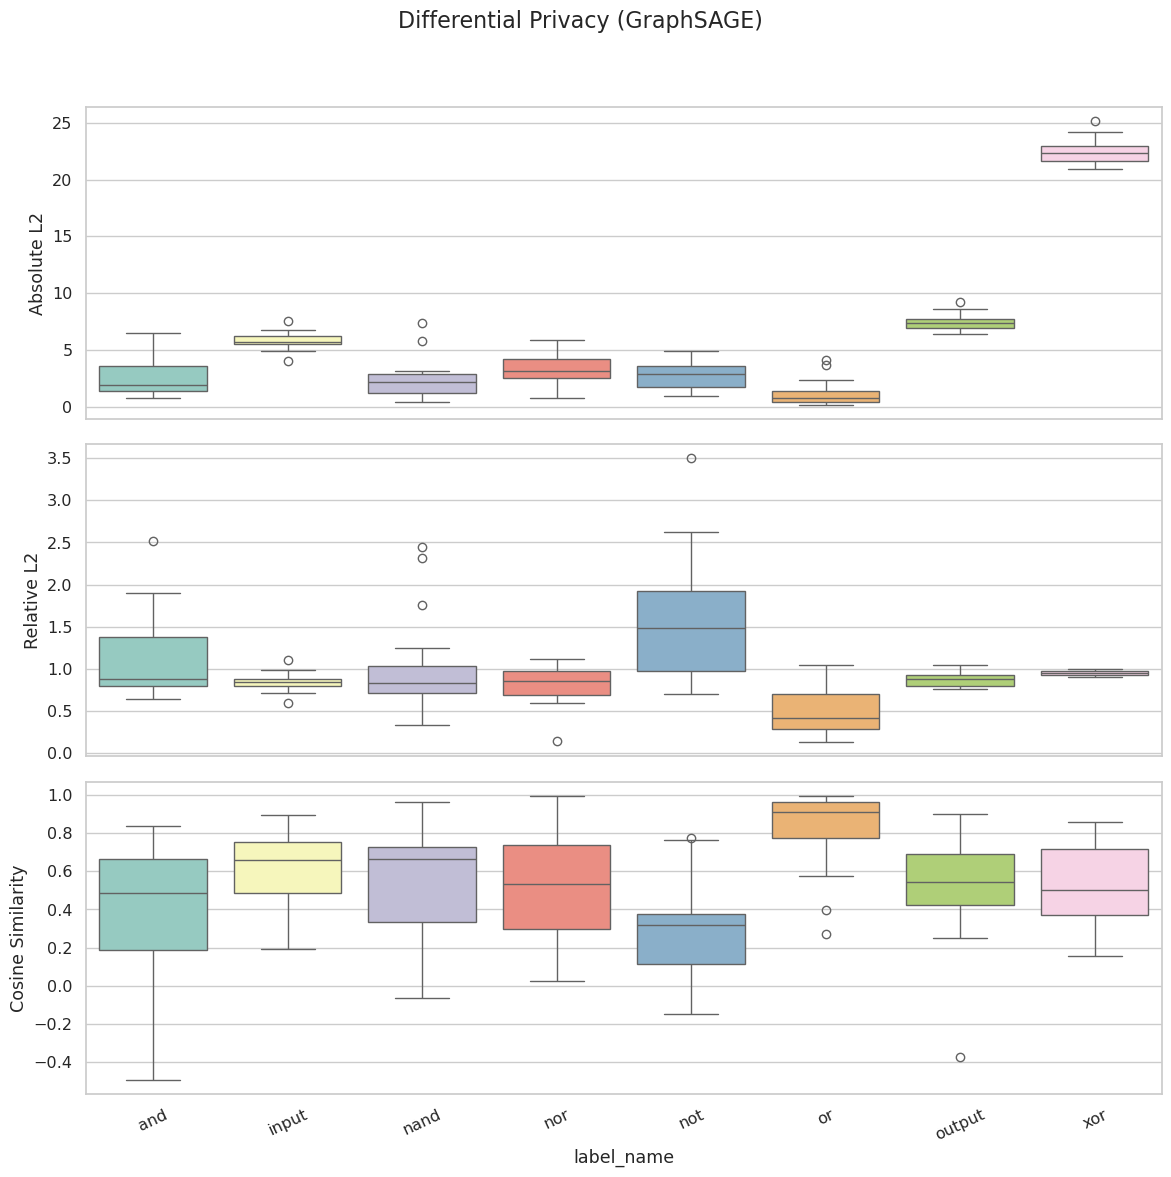


Summary for Differential Privacy (GraphSAGE):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.475944  1.560185    20  1.122483  0.497427    20  0.366793   
input        5.864973  0.713155    20  0.855013  0.102830    20  0.601250   
nand         2.363702  1.713670    20  1.017645  0.552462    20  0.534969   
nor          3.320907  1.457909    20  0.830591  0.227223    20  0.519248   
not          2.711439  1.145575    20  1.570091  0.745586    20  0.290417   
or           1.172817  1.098852    20  0.492461  0.286985    20  0.823463   
output       7.375664  0.728711    20  0.877897  0.078440    20  0.531527   
xor         22.409962  1.149714    20  0.954176  0.027591    20  0.514443   

                            
                 std count  
label_name                  
and         0.4018

/tmp/ipykernel_129597/1155840716.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_129597/1155840716.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_129597/1155840716.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


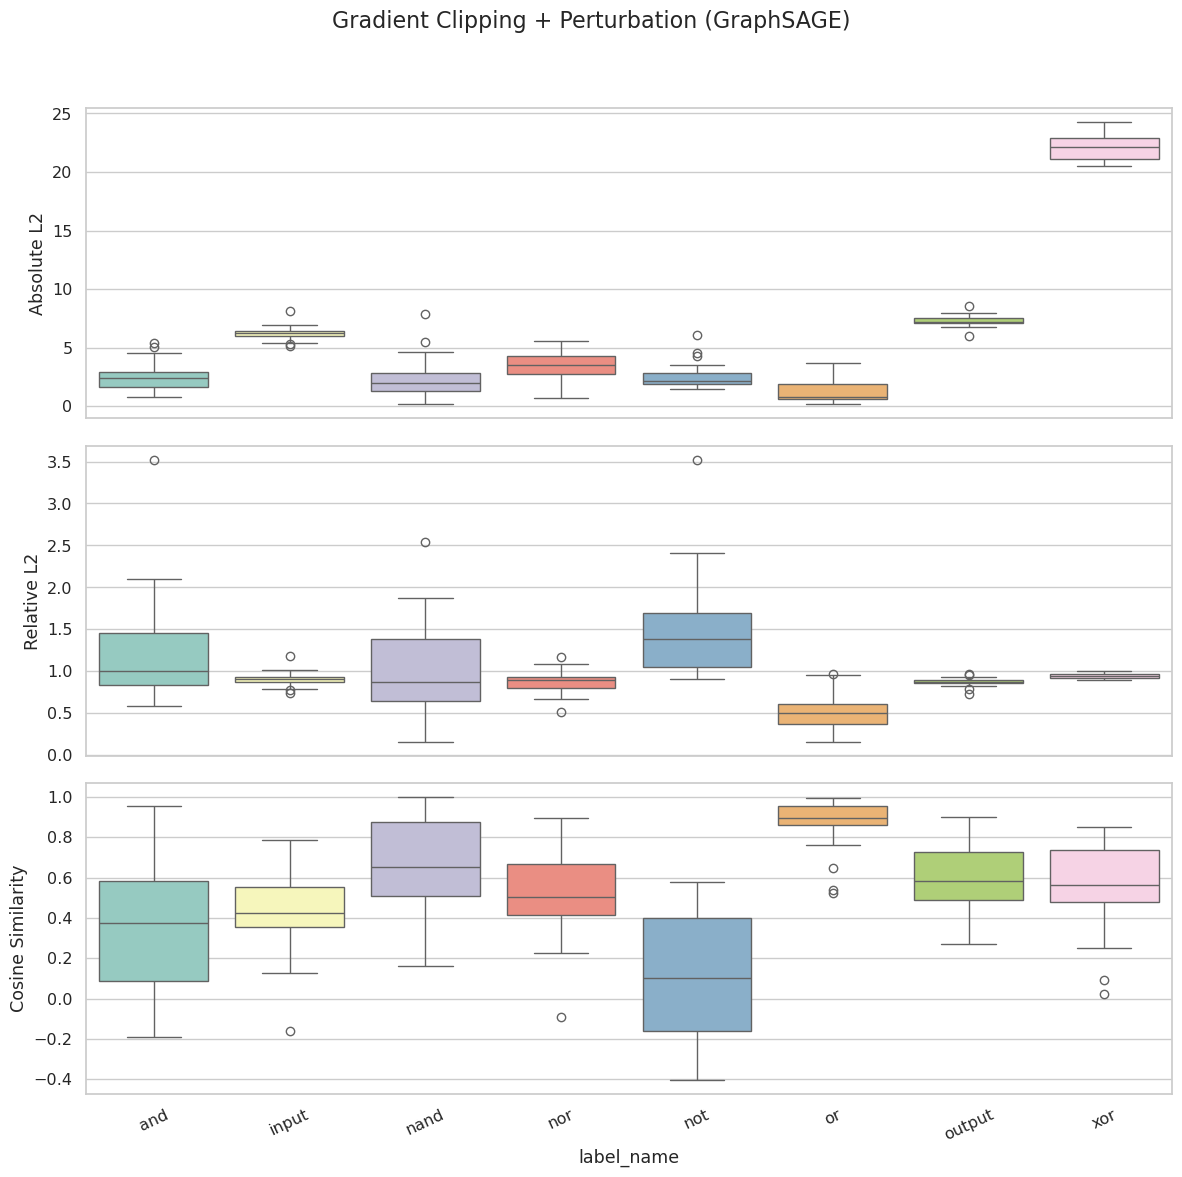


Summary for Gradient Clipping + Perturbation (GraphSAGE):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.567635  1.266454    20  1.271555  0.685415    20  0.340584   
input        6.225569  0.632755    20  0.907776  0.092251    20  0.438564   
nand         2.369267  1.845294    20  1.039124  0.611512    20  0.644326   
nor          3.556484  1.239514    20  0.878199  0.153375    20  0.513768   
not          2.623769  1.196445    20  1.508602  0.627387    20  0.116295   
or           1.288039  1.055809    20  0.531740  0.228332    20  0.862387   
output       7.323464  0.521916    20  0.871804  0.053526    20  0.590412   
xor         22.209942  1.091285    20  0.945789  0.029222    20  0.544331   

                            
                 std count  
label_name                  
and   

/tmp/ipykernel_129597/1155840716.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_129597/1155840716.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_129597/1155840716.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


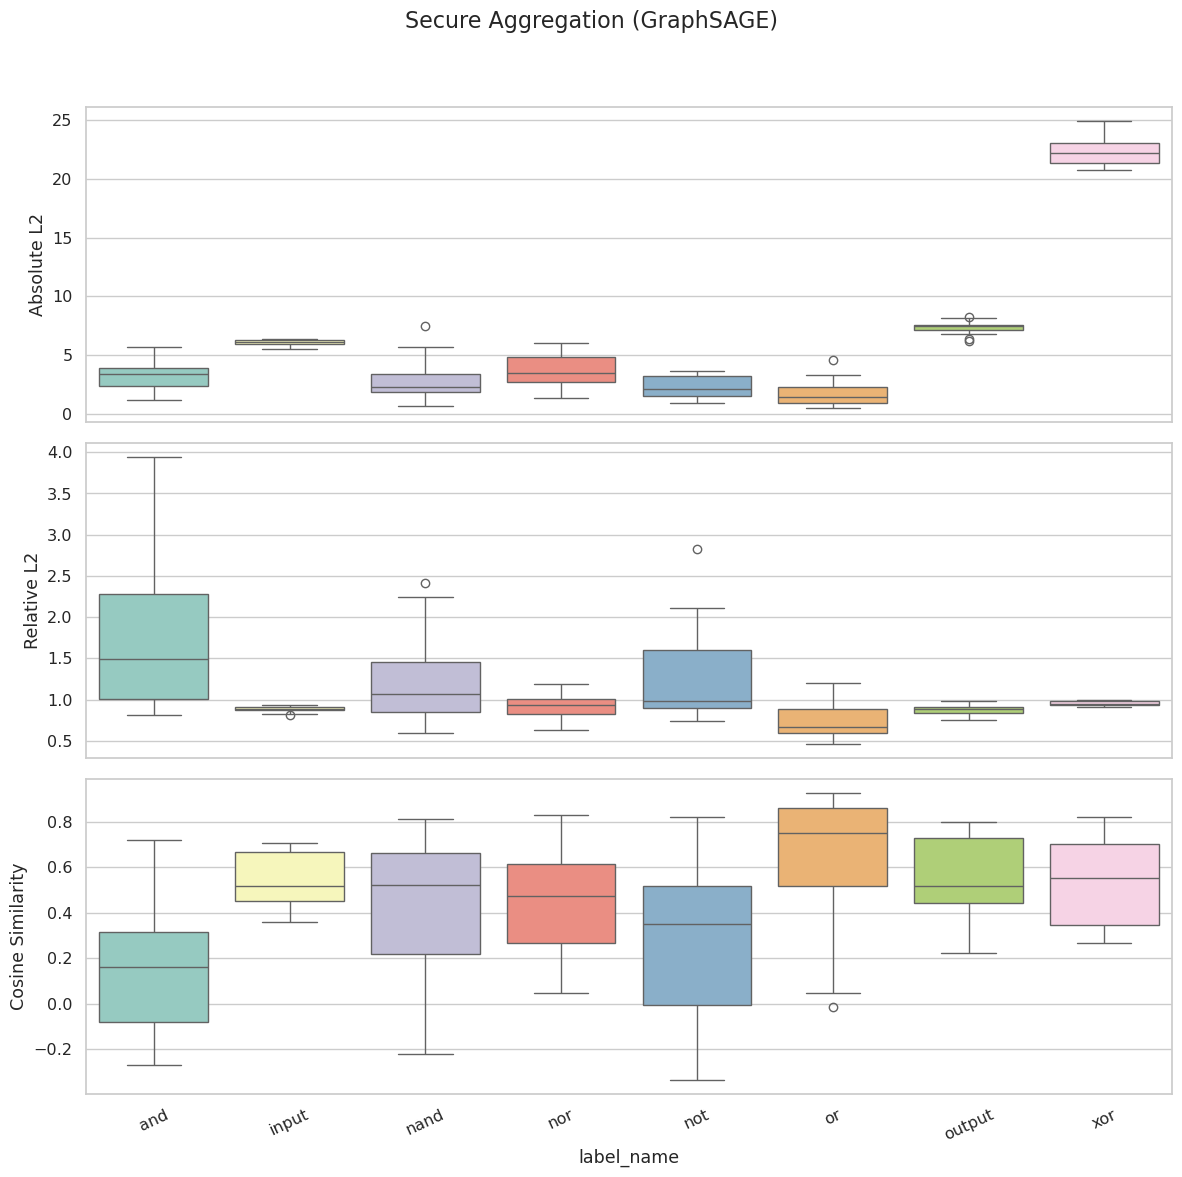


Summary for Secure Aggregation (GraphSAGE):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          3.276096  1.141338    20  1.698734  0.823957    20  0.135243   
input        6.061573  0.268259    20  0.883725  0.035532    20  0.539401   
nand         2.841583  1.789369    20  1.240863  0.533850    20  0.421910   
nor          3.711854  1.302323    20  0.926348  0.139885    20  0.440218   
not          2.283534  0.998009    20  1.297217  0.575637    20  0.258152   
or           1.702263  1.061279    20  0.745665  0.213060    20  0.647372   
output       7.357008  0.526654    20  0.876026  0.058763    20  0.548738   
xor         22.315752  1.182307    20  0.950070  0.027082    20  0.535897   

                            
                 std count  
label_name                  
and         0.279222

/tmp/ipykernel_129597/1155840716.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_129597/1155840716.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_129597/1155840716.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


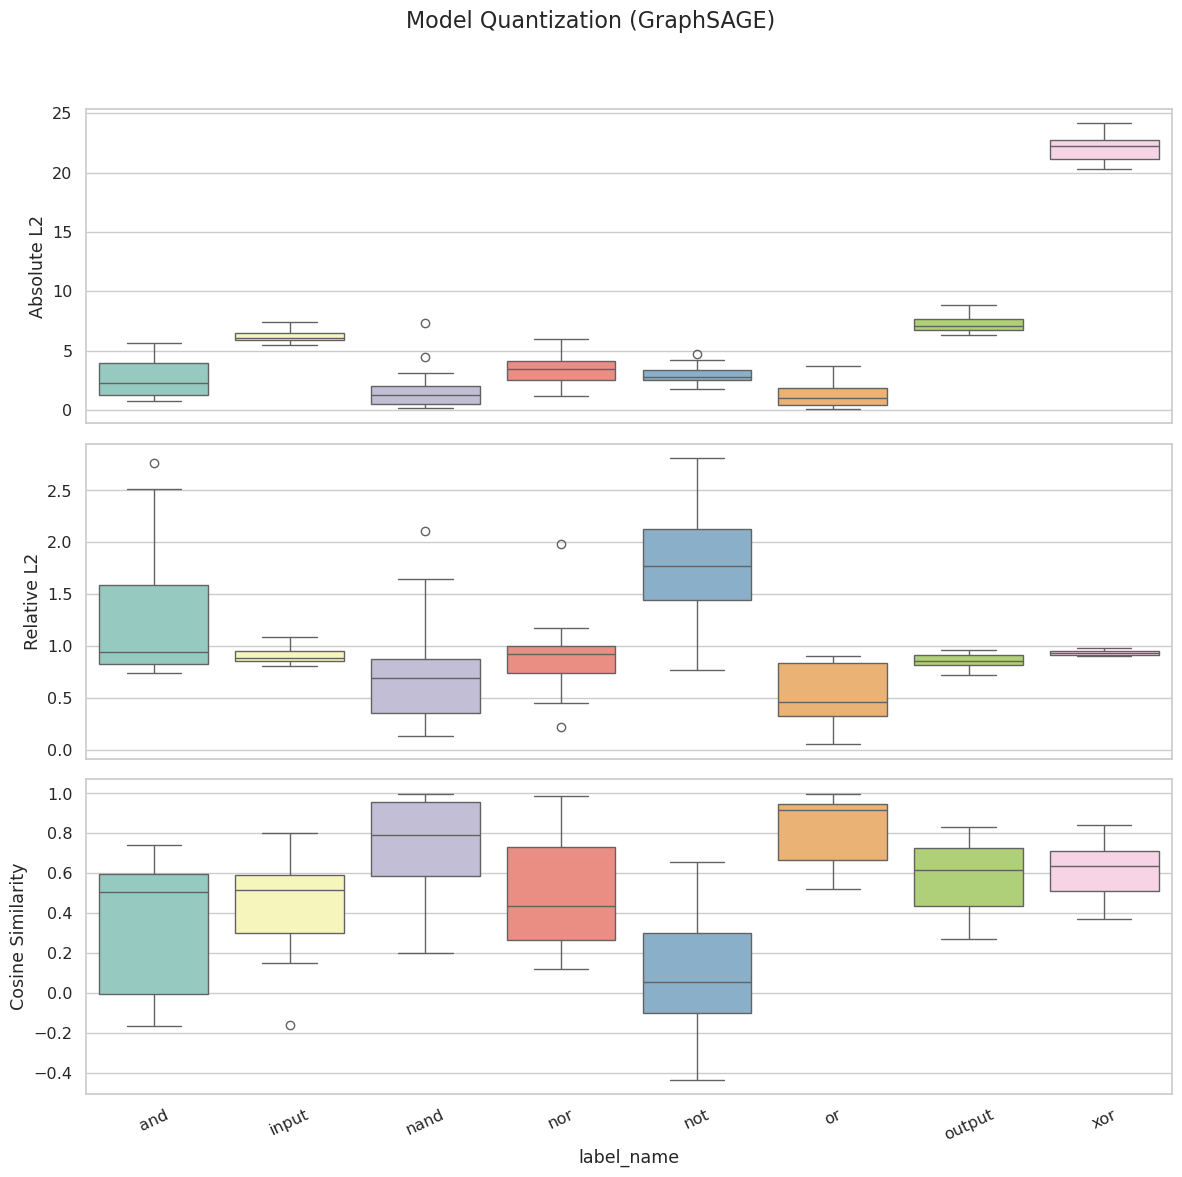


Summary for Model Quantization (GraphSAGE):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.716623  1.508987    20  1.270207  0.617493    20  0.339405   
input        6.238984  0.516532    20  0.909756  0.075704    20  0.445777   
nand         1.700446  1.709412    20  0.713632  0.512696    20  0.745482   
nor          3.405942  1.356175    20  0.891818  0.351960    20  0.511331   
not          2.989925  0.766008    20  1.788964  0.592766    20  0.083846   
or           1.265535  1.066075    20  0.511397  0.288335    20  0.821243   
output       7.239547  0.620248    20  0.861462  0.060535    20  0.584428   
xor         22.015879  1.112118    20  0.937315  0.023248    20  0.620925   

                            
                 std count  
label_name                  
and         0.325537

/tmp/ipykernel_129597/1155840716.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_129597/1155840716.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_129597/1155840716.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


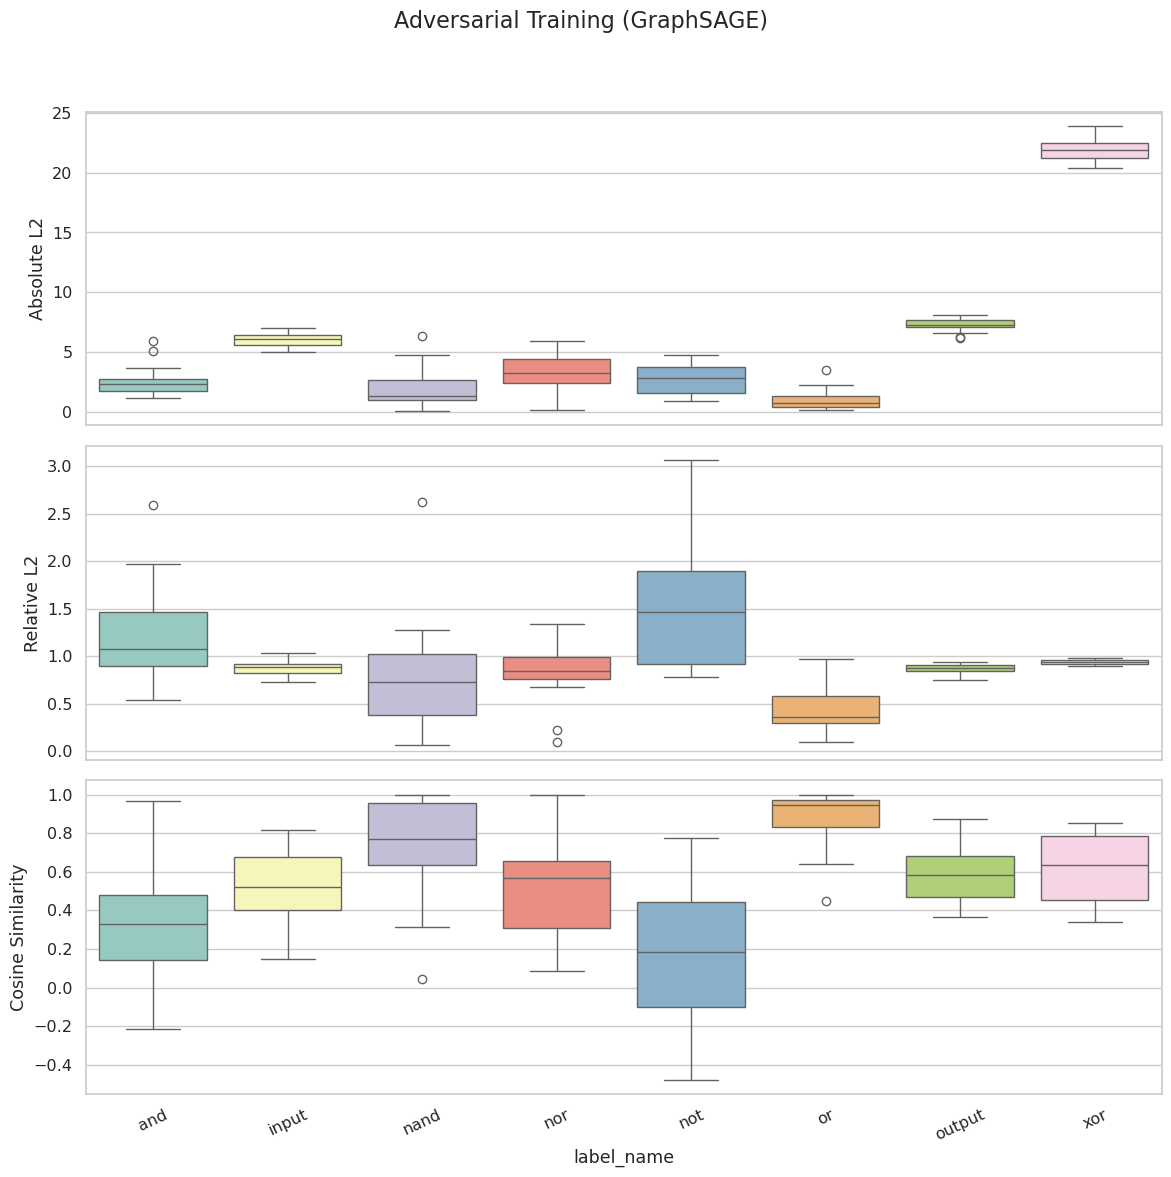


Summary for Adversarial Training (GraphSAGE):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.516120  1.205232    20  1.236102  0.492150    20  0.316308   
input        5.980707  0.529698    20  0.871969  0.075947    20  0.529596   
nand         1.852844  1.521950    20  0.796719  0.546571    20  0.723204   
nor          3.390575  1.464992    20  0.829511  0.278527    20  0.517095   
not          2.755701  1.287775    20  1.526211  0.629055    20  0.162456   
or           0.990369  0.801711    20  0.439932  0.247883    20  0.875508   
output       7.289022  0.532079    20  0.867594  0.053973    20  0.581294   
xor         22.031458  0.991256    20  0.938192  0.022064    20  0.623857   

                            
                 std count  
label_name                  
and         0.2756

In [9]:
# CELL 8: Plotting all GraphSAGE results
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, os

sns.set(style="whitegrid", font_scale=1.05)

files = {
    "Differential Privacy": "results_graphSAGE_dp.csv",
    "Gradient Clipping + Perturbation": "results_graphSAGE_gradclip_perturb.csv",
    "Secure Aggregation": "results_graphSAGE_secureagg.csv",
    "Model Quantization": "results_graphSAGE_quant.csv",
    "Adversarial Training": "results_graphSAGE_advtrain.csv"
}

for pretty_name, fname in files.items():
    if not os.path.exists(fname):
        print(f"Warning: {fname} not found  skipping {pretty_name}")
        continue
    df = pd.read_csv(fname)
    if df.empty:
        print(f"{fname} is empty  skip")
        continue

    order = sorted(df["label"].unique())
    label_order = [df[df["label"]==l]["label_name"].iloc[0] for l in order]

    fig, axs = plt.subplots(3,1, figsize=(12,12), sharex=True)
    fig.suptitle(f"{pretty_name} (GraphSAGE)", fontsize=16)

    sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
    axs[0].set_ylabel("Absolute L2"); axs[0].tick_params(axis="x", rotation=25)

    sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
    axs[1].set_ylabel("Relative L2"); axs[1].tick_params(axis="x", rotation=25)

    sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")
    axs[2].set_ylabel("Cosine Similarity"); axs[2].tick_params(axis="x", rotation=25)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    print(f"\nSummary for {pretty_name} (GraphSAGE):")
    print(df.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))
